# Principal Component Analysis

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## example of PCA reducing processing time using KNN method processing Cancer data

In [166]:
data = pd.read_csv('Cancer_Data.csv')
data.drop(columns = data.columns[-1], inplace = True)

# The data is categorized into two categories: Malignant and Benign
# This is summarized in the table as "diagnosis" column

# The "diagnosis" column is thus the target
y = data["diagnosis"]
# characteristics -- everything other than id and diagnosis result
X = data.iloc[:,2:]

In [167]:
from pathlib import Path
import sys
# Make sure we can import from the src/ directory
ROOT_DIR = Path.cwd().parents[2]      # project root (…/CMOR438)
SRC_PATH = ROOT_DIR / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from rice_ml.unsupervised_learning.pca import PCA
from rice_ml.supervised_learning.k_nearest_neighbors import KNNClassifier
from rice_ml.supervised_learning.k_nearest_neighbors import KNNRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [168]:
#standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [169]:
# Some data are used as training data, while others are used as testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)   # 20% of the data is used for test, 80% used as training data
pca = PCA(n_components=1)
pca.fit(X_train)
X_train_reduction = pca.transform(X_train)
X_test_reduction = pca.transform(X_test)


In [170]:
%%time
knn_clf = KNNClassifier()
knn_clf.fit(X_train, y_train)
knn_clf.score(X_test, y_test)

CPU times: user 51.4 ms, sys: 55.7 ms, total: 107 ms
Wall time: 16.2 ms


0.9385964912280702

In [171]:
%%time
knn_clf = KNNClassifier()
knn_clf.fit(X_train_reduction, y_train)
knn_clf.score(X_train_reduction, y_train)

CPU times: user 31.8 ms, sys: 11.5 ms, total: 43.3 ms
Wall time: 6.18 ms


0.9208791208791208

This reflects that PCA shortens the processing time. (Here, an example of knn algorithm is used.)

---
## Some better illustration of looking at graphs.

### A visualization using simple numbers.

X shape: (800, 8)

 k | cum_explained_var | recon_MSE
-----------------------------------
 1 |          0.790930 |  0.749906
 2 |          0.995184 |  0.017273
 3 |          0.996065 |  0.014115
 4 |          0.996930 |  0.011012
 5 |          0.997789 |  0.007930
 6 |          0.998608 |  0.004993
 7 |          0.999352 |  0.002326
 8 |          1.000000 |  0.000000


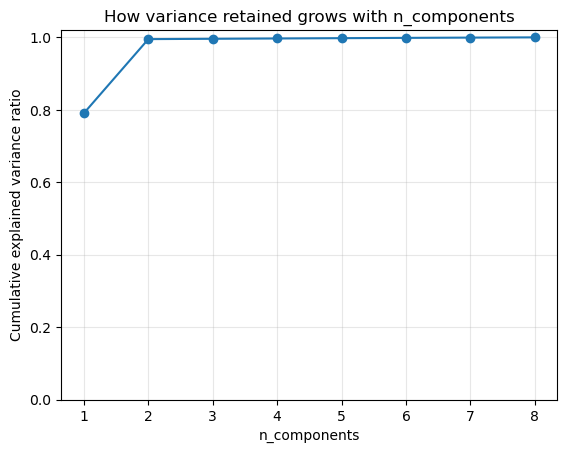

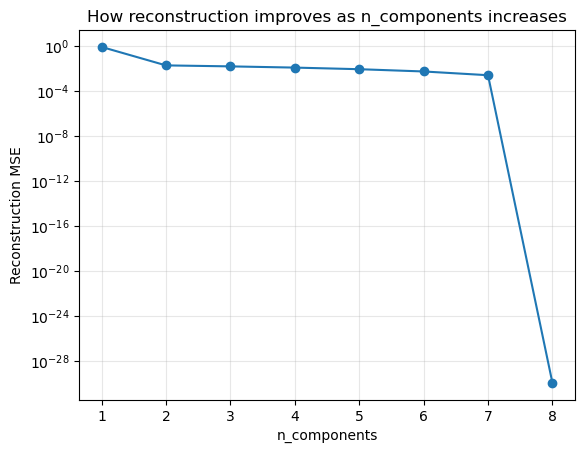

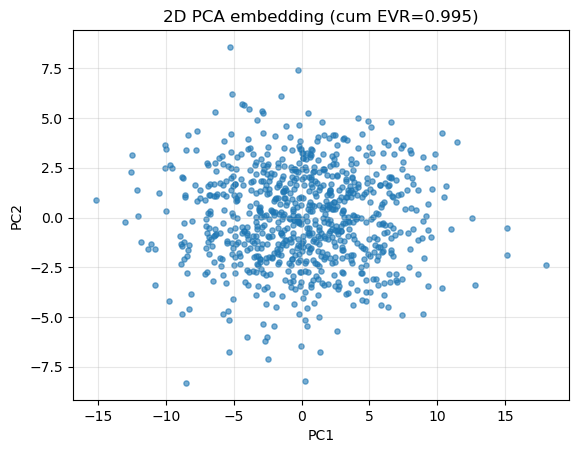

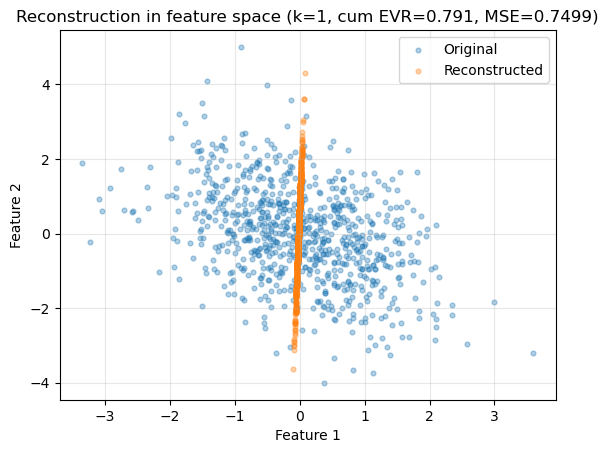

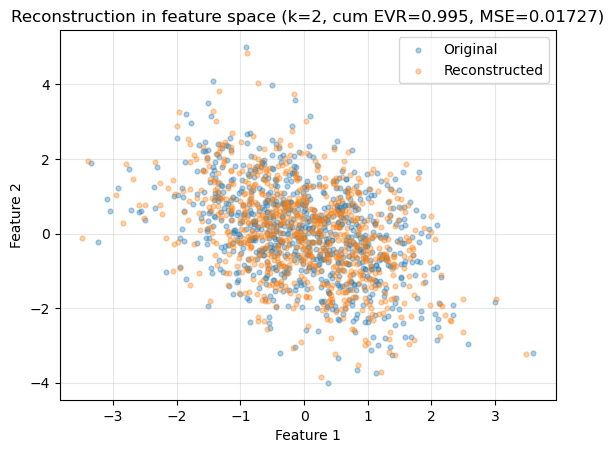

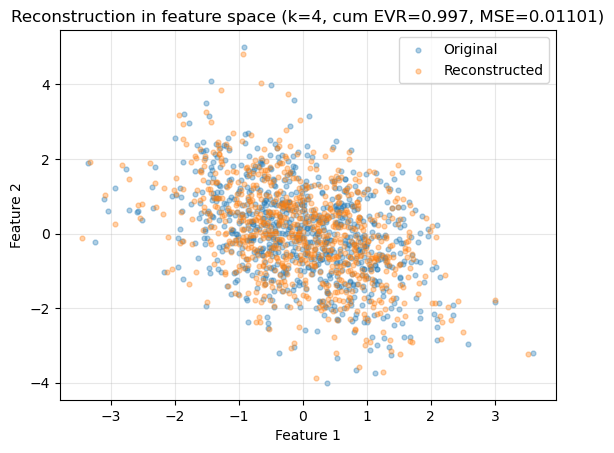

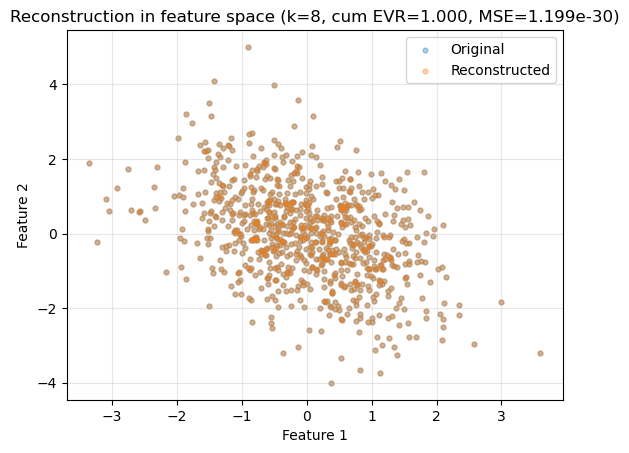

In [172]:
# -----------------------------
# 1) Synthetic data with *true* low dimension (2D) embedded in higher-D
# -----------------------------
rng = np.random.default_rng(0)
n_samples = 800
n_features = 8
true_latent_dim = 2

Z_true = rng.normal(size=(n_samples, true_latent_dim))           # latent 2D factors
A = rng.normal(size=(true_latent_dim, n_features))               # mixing matrix
noise = 0.15 * rng.normal(size=(n_samples, n_features))          # small noise
X = Z_true @ A + noise                                           # (800, 8)

print("X shape:", X.shape)


# -----------------------------
# 2) Sweep n_components: track explained variance + reconstruction MSE
# -----------------------------
max_k = min(n_samples, n_features)
ks = np.arange(1, max_k + 1)

cum_evr = []
mse = []

for k in ks:
    pca = PCA(n_components=int(k)).fit(X)
    X_hat = pca.inverse_transform(pca.transform(X))
    cum_evr.append(float(np.sum(pca.explained_variance_ratio_)))
    mse.append(float(np.mean((X - X_hat) ** 2)))

cum_evr = np.array(cum_evr)
mse = np.array(mse)

# Print a small table
print("\n k | cum_explained_var | recon_MSE")
print("-----------------------------------")
for k, ev, err in zip(ks, cum_evr, mse):
    print(f"{k:2d} | {ev:17.6f} | {err:9.6f}")


# -----------------------------
# 3) Plot A: cumulative explained variance vs n_components
# -----------------------------
plt.figure()
plt.plot(ks, cum_evr, marker="o")
plt.xlabel("n_components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("How variance retained grows with n_components")
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.show()


# -----------------------------
# 4) Plot B: reconstruction MSE vs n_components (log scale helps)
# -----------------------------
plt.figure()
plt.plot(ks, mse, marker="o")
plt.xlabel("n_components")
plt.ylabel("Reconstruction MSE")
plt.title("How reconstruction improves as n_components increases")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.show()


# -----------------------------
# 5) Plot C: 2D PCA embedding (n_components=2)
# -----------------------------
pca2 = PCA(n_components=2).fit(X)
X2 = pca2.transform(X)

plt.figure()
plt.scatter(X2[:, 0], X2[:, 1], s=14, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    f"2D PCA embedding (cum EVR={pca2.explained_variance_ratio_.sum():.3f})"
)
plt.grid(True, alpha=0.3)
plt.show()


# -----------------------------
# 6) Plot D: original vs reconstructed (feature1 vs feature2) for different n_components
# -----------------------------
for k in [1, 2, 4, 8]:
    pca = PCA(n_components=k).fit(X)
    X_hat = pca.inverse_transform(pca.transform(X))
    err = np.mean((X - X_hat) ** 2)

    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], s=12, alpha=0.35, label="Original")
    plt.scatter(X_hat[:, 0], X_hat[:, 1], s=12, alpha=0.35, label="Reconstructed")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(
        f"Reconstruction in feature space (k={k}, cum EVR={pca.explained_variance_ratio_.sum():.3f}, MSE={err:.4g})"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()




Cumulative EVR curve rises quickly and then flattens.

Reconstruction MSE drops fast early (big gains) then shows diminishing returns.

In the feature-space overlay, reconstructed points match the original better as k increases.

---
### Another example demonstrating what important imformation is extracted from the original data
using facial recognition data as an example.

In [173]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
faces.images.shape


(1348, 62, 47)

In [174]:
faces
# 

{'data': array([[0.53333336, 0.52418303, 0.49673203, ..., 0.00653595, 0.00653595,
         0.00130719],
        [0.28627452, 0.20784314, 0.2535948 , ..., 0.96993464, 0.95032686,
         0.9346406 ],
        [0.31633988, 0.3895425 , 0.275817  , ..., 0.4261438 , 0.7895425 ,
         0.9555555 ],
        ...,
        [0.11633987, 0.11111111, 0.10196079, ..., 0.5660131 , 0.579085  ,
         0.5542484 ],
        [0.19346406, 0.21045752, 0.29150328, ..., 0.6875817 , 0.6575164 ,
         0.5908497 ],
        [0.12418301, 0.09673203, 0.10849673, ..., 0.12941177, 0.16209151,
         0.29150328]], dtype=float32),
 'images': array([[[0.53333336, 0.52418303, 0.49673203, ..., 0.2653595 ,
          0.2653595 , 0.26013073],
         [0.56993467, 0.545098  , 0.4797386 , ..., 0.2627451 ,
          0.2627451 , 0.26013073],
         [0.5882353 , 0.5398693 , 0.475817  , ..., 0.2640523 ,
          0.26013073, 0.25751635],
         ...,
         [0.59738564, 0.7176471 , 0.40261438, ..., 0.00653595,
     

In [175]:
X = faces.data
X.shape
# in data (characteristic matrix), each row is a sample
# each column is all cahracteristics related to the sample

(1348, 2914)

In [176]:
# images are in 3D array
faces.images.shape
# 1348 is the number of images
# 62 is the number of rows of the characteristic matrix
# 47 is the number of columns of the characteristic matrix

(1348, 62, 47)

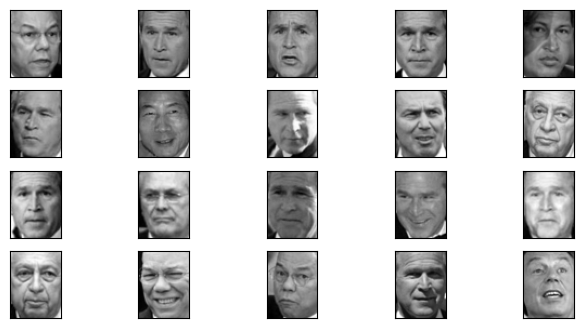

In [177]:
fig, axes = plt.subplots (4,5, figsize = (8,4), subplot_kw = {"xticks":[], "yticks":[]})


# fill in the original graphs
for i, ax, in enumerate (axes.flat):
    ax.imshow(faces.images[i, :, :], cmap = 'gray')

Now, PCA is used to only look at certain features of these graphs.

In [178]:
pca = PCA(n_components=150).fit(X)
V = pca.components_
V.shape
# The shape of V has reduced to # n_components

(150, 2914)

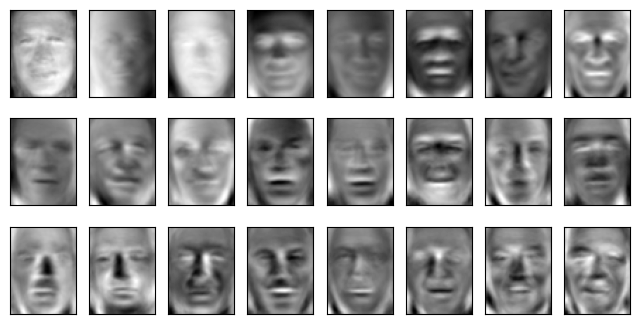

In [179]:
# visualize the new characteristic matrix
fig, axes = plt.subplots (3,8, figsize = (8,4), subplot_kw = {"xticks":[], "yticks":[]})


# fill in the graphs
for i, ax, in enumerate (axes.flat):
    ax.imshow(V[i, :].reshape(62,47), cmap = 'gray')

From the comparison of the graphs, it's clear that the highlights and the shadows of a human face is clear. Typical facial organs (such as eyes, nose, mouth) are relatively clear as well. Other features of the face are less clear. This shows that after PCA, the new characteristic matrix is likely about lightness and facial organs.